In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
mpl.rcParams['figure.dpi'] = 85

In [3]:
color_all = ['cyan','orange','blue','green','purple','magenta','brown','gray','hazy gray']

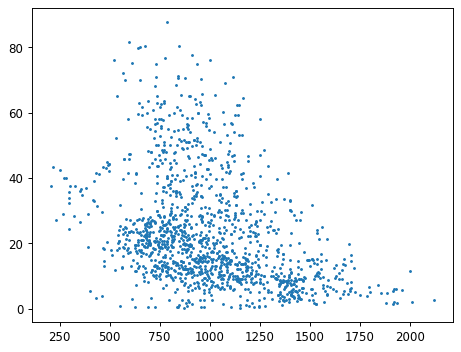

In [4]:
full_set = pd.read_csv('Data/literature_data.csv')
plt.scatter(full_set['UTS'], full_set['UE'],s=2.)

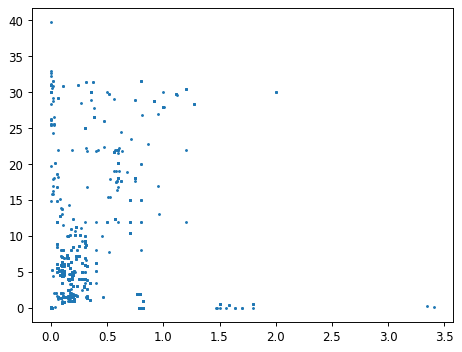

In [5]:
plt.scatter(full_set['C'], full_set['Mn'],s=2)

In [6]:
std_uts = np.std(full_set['UTS'])
std_ue = np.std(full_set['UE'])

In [7]:
select_all = []
for i in range(6):
    data = pd.read_excel('Data/Data selected for SDI calculation.xlsx',sheet_name=i,header=0)
    select_all.append(data)

In [8]:
for i in range(6):
    select_all[i]['UTS'] = select_all[i]['UTS'].values/std_uts
    select_all[i]['UE'] = select_all[i]['UE'].values/std_ue

Text(0, 0.5, 'Ultimate elongation (UE)')

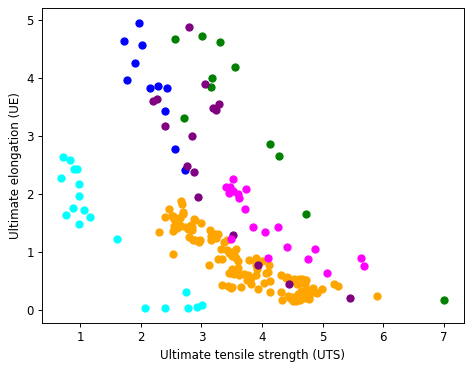

In [9]:
for i in range(6):
    plt.scatter(select_all[i]['UTS'],select_all[i]['UE'],color=color_all[i])
plt.xlabel('Ultimate tensile strength (UTS)')
plt.ylabel('Ultimate elongation (UE)')
#plt.legend()

## chemical composition + processing (microstructure) ----> mechanical properties 

## what can we predict with chemical compositions only?

At a given composition, we have a probability distribution for UTS and UE because microstructures are not known.

Let's first assume it is a two-dimensional Gaussian distribution

In [10]:
from sklearn.mixture import GaussianMixture

In [11]:
model = GaussianMixture(n_components=1,covariance_type='full')

In [12]:
cov_all = []
mean_all = []
a_all = []
b_all = []
slope_all = []
intercept_all = []
label_all=[]
for i in range(len(select_all)):
    model.fit(select_all[i][['UTS','UE']])
    cov = model.covariances_[0]
    cov_all.append(cov)
    mean = model.means_[0]
    mean_all.append(mean)
    v, w = np.linalg.eigh(cov)
    a_all.append(-w[0][1])
    b_all.append(-w[0][0])
    slope = -w[0][0] / w[0][1]
    slope_all.append(slope)
    intercept_all.append(mean[1]-mean[0] * slope) 

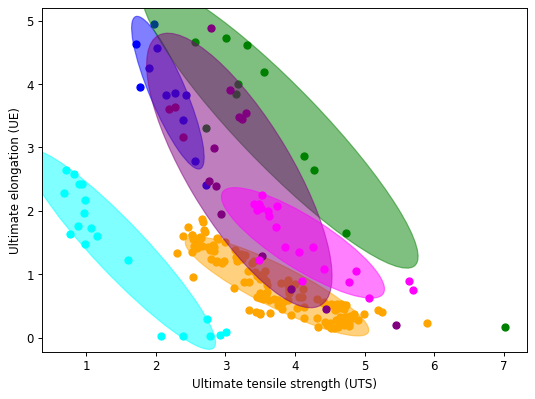

In [13]:
ax = plt.subplot()
for i in range(len(select_all)):
    data = select_all[i]
    mean = mean_all[i]
    cov = cov_all[i]
    color = color_all[i]
    # Plot an ellipse to show the Gaussian component
    v, w = np.linalg.eigh(cov)
    angle = np.arctan2(w[0][1], w[0][0])
    angle = 180. * angle / np.pi  # convert to degrees
    s = np.sqrt(v)
    ax.scatter(data['UTS'],data['UE'],color=color )
    ell = mpl.patches.Ellipse(mean, s[0]*3.29, s[1]*3.29, angle=angle, color=color)
    ell.set_alpha(.5)
    ax.add_artist(ell)

plt.xlabel('Ultimate tensile strength (UTS)')
plt.ylabel('Ultimate elongation (UE)')
plt.tight_layout()
plt.savefig('ellipse', dpi=200, bbox_inches='tight', transparent=True)

the two-dimensonal Gaussian distributions are very anisotropic. 

Rough assumptions:
1. The covariance matrices of the 2D Gaussian distributions have the same eigenvectors. (Ellipses have the same orientation).
2. the mean values projected onto the minimum-variance direction (minor-axis of ellipse) are a function of chemical compositions.

$SDI = \frac{UTS}{a} + \frac{UE}{b}$

$SDI = f(c_{C}, c_{Mn}, c_{Al}, c_{Si}, c_{Fe} )$

In [14]:
a_mean = np.mean(a_all)
b_mean = np.mean(b_all)

In [15]:
a_unit = a_mean * std_uts

In [16]:
b_unit = b_mean * std_ue

In [17]:
slope_mean = np.mean(slope_all)
ba_mean = np.arctan(-b_mean/a_mean)/np.pi*180
import math
angle = math.radians(ba_mean)
tan_value = math.tan(angle)

In [18]:
SDI = full_set['UTS'].values / a_unit + full_set['UE'] / b_unit

In [19]:
full_set['SDI'] = SDI
full_set

,C,Mn,Al,Si,Fe,UTS,UE,SDI
0,0.60,12.00,0.0,0.0,87.40,830.00000,27.60000,6.581325
1,0.30,12.00,3.0,0.0,84.70,943.20000,46.30000,8.718947
2,0.05,6.15,0.0,1.5,92.30,1014.00000,20.00000,6.901350
3,0.05,6.15,0.0,1.5,92.30,1099.00000,13.80000,6.825925
4,0.05,6.15,0.0,1.5,92.30,1213.00000,9.50000,7.058133
...,...,...,...,...,...,...,...,...
1368,1.48,0.00,0.0,0.0,98.52,399.01409,5.49224,2.518297
1369,1.64,0.00,0.0,0.0,98.36,430.83987,3.19432,2.492006
1370,1.64,0.00,0.0,0.0,98.36,761.22182,12.15548,4.943580
1371,1.56,0.00,0.0,0.0,98.44,767.66275,6.36459,4.496088


In [20]:
full_set.to_csv('Data/literature_data_SDI.csv',index=False)